In [246]:
%pip install gdown

Note: you may need to restart the kernel to use updated packages.


In [247]:
import gdown
import zipfile
import os

# Google Drive 공유 링크
url = "https://drive.google.com/file/d/1Gyk5STLl_ghJ81FS90NynAPOGc_ojSR0/view?usp=drive_link"

# gdown이 이해할 수 있는 ID 형식으로 변환
file_id = url.split("/d/")[1].split("/")[0]
download_url = f"https://drive.google.com/uc?id={file_id}"

# 저장할 파일 이름
output = "downloaded_file.zip"

# 1. 구글 드라이브에서 다운로드
print("🔽 파일 다운로드 중...")
gdown.download(download_url, output, quiet=False)

# 2. 압축 해제 (zip 파일일 경우)
extract_dir = "extracted_files"
os.makedirs(extract_dir, exist_ok=True)

print("📦 압축 해제 중...")
with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"✅ 압축 해제 완료! 경로: {os.path.abspath(extract_dir)}")

🔽 파일 다운로드 중...


Downloading...
From: https://drive.google.com/uc?id=1Gyk5STLl_ghJ81FS90NynAPOGc_ojSR0
To: c:\김지은\파이썬_src\pandas-data-analysis\part7\downloaded_file.zip
100%|██████████| 16.8M/16.8M [00:00<00:00, 21.1MB/s]


📦 압축 해제 중...
✅ 압축 해제 완료! 경로: c:\김지은\파이썬_src\pandas-data-analysis\part7\extracted_files


In [248]:
import pandas as pd
import numpy as np
train = pd.read_csv('./extracted_files/open/train.csv')
train.head()

,ID,사고일시,요일,기상상태,시군구,도로형태,노면상태,사고유형,사고유형 - 세부분류,법규위반,...,가해운전자 상해정도,피해운전자 차종,피해운전자 성별,피해운전자 연령,피해운전자 상해정도,사망자수,중상자수,경상자수,부상자수,ECLO
0,ACCIDENT_00000,2019-01-01 00,화요일,맑음,대구광역시 중구 대신동,단일로 - 기타,건조,차대사람,길가장자리구역통행중,안전운전불이행,...,상해없음,보행자,여,70세,중상,0,1,0,0,5
1,ACCIDENT_00001,2019-01-01 00,화요일,흐림,대구광역시 달서구 감삼동,단일로 - 기타,건조,차대사람,보도통행중,기타,...,상해없음,보행자,남,61세,경상,0,0,1,0,3
2,ACCIDENT_00002,2019-01-01 01,화요일,맑음,대구광역시 수성구 두산동,단일로 - 기타,건조,차대사람,차도통행중,안전운전불이행,...,상해없음,보행자,남,38세,경상,0,0,1,0,3
3,ACCIDENT_00003,2019-01-01 02,화요일,맑음,대구광역시 북구 복현동,단일로 - 기타,건조,차대차,추돌,안전운전불이행,...,상해없음,승용,남,36세,중상,0,1,0,0,5
4,ACCIDENT_00004,2019-01-01 04,화요일,맑음,대구광역시 동구 신암동,단일로 - 기타,건조,차대차,추돌,안전운전불이행,...,상해없음,승용,남,52세,경상,0,0,1,0,3


In [249]:

# 정수형 변환 함수
import re
def extraced_and_convert_to_int(data):
    numbers = re.findall(r'\d+',str(data))
    return int(numbers[0]) if numbers else np.nan
train['가해운전자 연령'] = train['가해운전자 연령'].apply(extraced_and_convert_to_int)
train['피해운전자 연령'] = train['피해운전자 연령'].apply(extraced_and_convert_to_int)

In [250]:
train.head()

,ID,사고일시,요일,기상상태,시군구,도로형태,노면상태,사고유형,사고유형 - 세부분류,법규위반,...,가해운전자 상해정도,피해운전자 차종,피해운전자 성별,피해운전자 연령,피해운전자 상해정도,사망자수,중상자수,경상자수,부상자수,ECLO
0,ACCIDENT_00000,2019-01-01 00,화요일,맑음,대구광역시 중구 대신동,단일로 - 기타,건조,차대사람,길가장자리구역통행중,안전운전불이행,...,상해없음,보행자,여,70.0,중상,0,1,0,0,5
1,ACCIDENT_00001,2019-01-01 00,화요일,흐림,대구광역시 달서구 감삼동,단일로 - 기타,건조,차대사람,보도통행중,기타,...,상해없음,보행자,남,61.0,경상,0,0,1,0,3
2,ACCIDENT_00002,2019-01-01 01,화요일,맑음,대구광역시 수성구 두산동,단일로 - 기타,건조,차대사람,차도통행중,안전운전불이행,...,상해없음,보행자,남,38.0,경상,0,0,1,0,3
3,ACCIDENT_00003,2019-01-01 02,화요일,맑음,대구광역시 북구 복현동,단일로 - 기타,건조,차대차,추돌,안전운전불이행,...,상해없음,승용,남,36.0,중상,0,1,0,0,5
4,ACCIDENT_00004,2019-01-01 04,화요일,맑음,대구광역시 동구 신암동,단일로 - 기타,건조,차대차,추돌,안전운전불이행,...,상해없음,승용,남,52.0,경상,0,0,1,0,3


In [251]:
# 데이터 기초 탐색 : 데이터의 크기, 구조 , 결측치, 중복값, 기술통계량, 고유값
def wrangling(train_set):
    print('---shape---')
    display(train_set.shape)

    print('---info---')
    display(train_set.info())

    print('---nan---')
    display(train_set.isna().sum())

    print('---duplication---')
    display(train_set[train_set.duplicated()])

    print('---describtion---')
    display(train_set.describe())

    print('---unique---')
    display(train_set.nunique()) # type : ignore
                                 # ^ unique 명령어

wrangling(train)

---shape---


(39609, 23)

---info---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39609 entries, 0 to 39608
Data columns (total 23 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           39609 non-null  object 
 1   사고일시         39609 non-null  object 
 2   요일           39609 non-null  object 
 3   기상상태         39609 non-null  object 
 4   시군구          39609 non-null  object 
 5   도로형태         39609 non-null  object 
 6   노면상태         39609 non-null  object 
 7   사고유형         39609 non-null  object 
 8   사고유형 - 세부분류  39609 non-null  object 
 9   법규위반         39609 non-null  object 
 10  가해운전자 차종     39609 non-null  object 
 11  가해운전자 성별     39609 non-null  object 
 12  가해운전자 연령     38615 non-null  float64
 13  가해운전자 상해정도   39609 non-null  object 
 14  피해운전자 차종     38618 non-null  object 
 15  피해운전자 성별     38618 non-null  object 
 16  피해운전자 연령     38549 non-null  float64
 17  피해운전자 상해정도   38618 non-null  object 
 18  사망자수         39609 non-null  int64 

None

---nan---


...

,ID,사고일시,요일,기상상태,시군구,도로형태,노면상태,사고유형,사고유형 - 세부분류,법규위반,...,가해운전자 상해정도,피해운전자 차종,피해운전자 성별,피해운전자 연령,피해운전자 상해정도,사망자수,중상자수,경상자수,부상자수,ECLO


---describtion---


,가해운전자 연령,피해운전자 연령,사망자수,중상자수,경상자수,부상자수,ECLO
count,38615.000000,38549.000000,39609.000000,39609.000000,39609.000000,39609.000000,39609.000000
mean,47.906176,44.699655,0.007776,0.262365,1.070085,0.126865,4.726704
std,16.060277,16.968567,0.090109,0.500845,0.992034,0.394670,3.207206
min,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,35.000000,31.000000,0.000000,0.000000,0.000000,0.000000,3.000000
50%,50.000000,45.000000,0.000000,0.000000,1.000000,0.000000,3.000000
75%,60.000000,58.000000,0.000000,0.000000,1.000000,0.000000,6.000000
max,98.000000,98.000000,2.000000,6.000000,22.000000,10.000000,74.000000


---unique---


ID             39609
사고일시           18057
요일                 7
기상상태               6
시군구              199
도로형태              11
노면상태               6
사고유형               3
사고유형 - 세부분류       14
법규위반              11
가해운전자 차종          12
가해운전자 성별           3
가해운전자 연령          87
가해운전자 상해정도         6
피해운전자 차종          13
피해운전자 성별           3
피해운전자 연령          95
피해운전자 상해정도         6
사망자수               3
중상자수               7
경상자수              18
부상자수               9
ECLO              46
dtype: int64

Malgun Gothic


<>:9: SyntaxWarning: invalid escape sequence '\p'
<>:9: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Playdata2\AppData\Local\Temp\ipykernel_2132\503066410.py:9: SyntaxWarning: invalid escape sequence '\p'
  font_path = "C:\김지은\파이썬_src\pandas-data-analysis\part7\data\MALGUN.TTF"   # 폰트파일의 위치


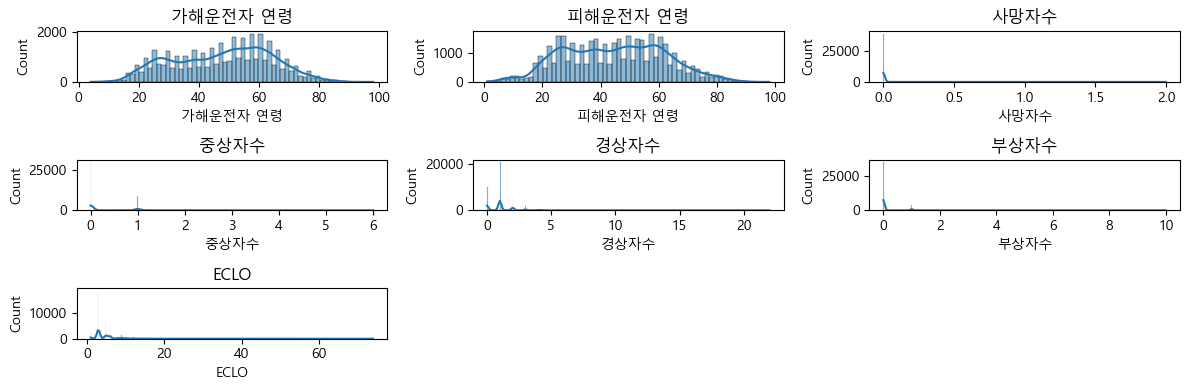

In [252]:
# 수치적 특성
# 문자열 데이터가 아닌 컬러만 모인 리스트 num_cols 를 이용해서 각컬럼별 분포를 확인
# 수치형 데이터들을 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# matplotlib 한글 폰트 오류 문제 해결
from matplotlib import font_manager, rc
font_path = "C:\김지은\파이썬_src\pandas-data-analysis\part7\data\MALGUN.TTF"   # 폰트파일의 위치
                                  # Windows - Fonts
font_name = font_manager.FontProperties(fname=font_path).get_name()
print(font_name) # Malgun Gothic
rc('font', family=font_name)

num_cols = train.select_dtypes(exclude='object').columns.to_list()  # 컬럼 중에서 object 객체인 컬럼들을 num_cols 리스트에 담는다.
plt.figure(figsize=(12,4))

for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(train[col], kde=True) # ^ kde : 부드러운 곡선으 표시할지 여부
    plt.title(col)                      # 각 subplot에 컬럼 이름 표시
plt.tight_layout()
plt.show()

In [253]:
# 범주형 데이터 확인
category_cols = train.select_dtypes(include='object').columns
len(category_cols)

16

In [254]:

# ID와 사고일시 컬럼 제외 14개의 컬럼으로 시작
category_cols = train.select_dtypes(include='object').columns[2:]
print(category_cols)

Index(['요일', '기상상태', '시군구', '도로형태', '노면상태', '사고유형', '사고유형 - 세부분류', '법규위반',
       '가해운전자 차종', '가해운전자 성별', '가해운전자 상해정도', '피해운전자 차종', '피해운전자 성별',
       '피해운전자 상해정도'],
      dtype='object')


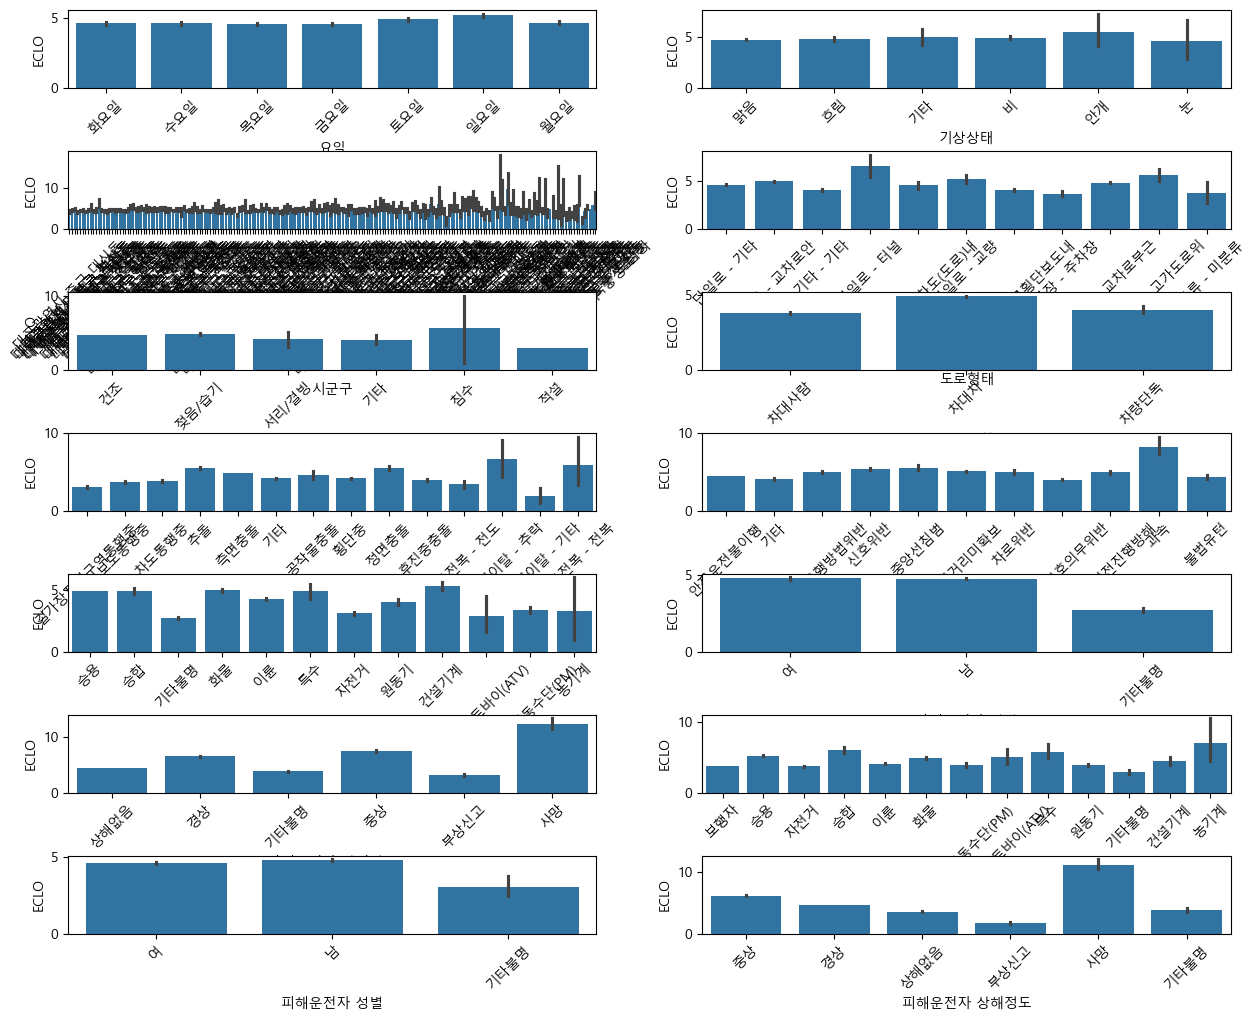

In [255]:
# 범주형 데이터 시각화
plt.figure(figsize=(15,12))

# 카테고리 많으면 자동 확대 설정 ^
# n_cat = len(train[col].unique())
# plt.figure(figsize=(max(8, n_cat * 0.6), 4))

for i, col in enumerate(category_cols):
    plt.subplot(7,2,i+1)
    sns.barplot(data=train,x=col,y='ECLO') # ECLO 심각도 ^
    plt.xticks(rotation=45) # 라벨 기울기 45도 
plt.tight_layout

plt.subplots_adjust(hspace=0.8)  # ← 그래프 세로 간격 넓히기 (0.5~1.0 사이 시도)

In [256]:
 # 사고 지역


In [257]:
# 시 군 구 의 정보를 가진 열컬럼을 구, 동을 나누어서 인명피해 심각도 ELCO 관계 탐색
train['구'] = train['시군구'].str.split(" ",expand=True)[1] # 빈칸으로 시군구를 분리하고 인덱스 1(구가 적혀져있는 항목)을 데이터프레임 형태로 반환
# expand=False (기본값) → 리스트로 반환
#  expand=True → 리스트의 각 요소를 **열(Column)**로 분리해서 DataFrame 형태로 반환
train['동'] = train['시군구'].str.split(" ",expand=True)[2] # 빈칸으로 시군구를 분리하고 인덱스 2(동이 적혀져있는 항목)을 데이터프레임 형태로 반환

#

C:\Users\Playdata2\AppData\Local\Temp\ipykernel_2132\1637158047.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train,x='가해운전자 연령',y='법규위반',palette='deep')


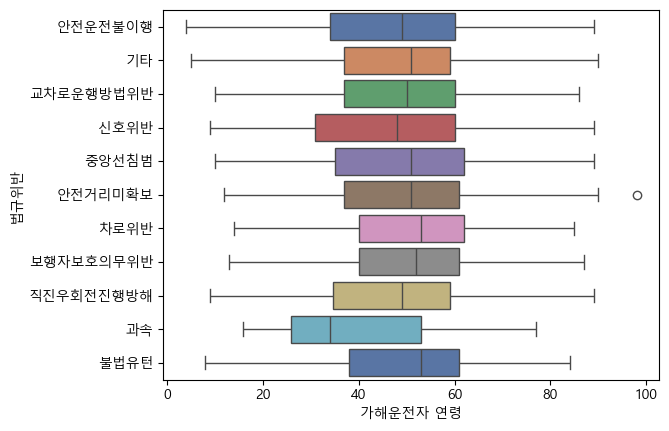

In [258]:
# 가해운전자의 연령 과 법규 위반 유형간의 관계 : boxplot
sns.boxplot(data=train,x='가해운전자 연령',y='법규위반',palette='deep')
plt.show()

# hue 파라미터가 어떤 상황에서 작동하고 어떤 상황에서는 막히는지를 설명해보자면,
# hue는 “범주에 따라 색을 나누는” 기능.
# 하지만 그래프의 축(y나 x)이 데이터가 있어야 색깔 표현이 가능하다.

<Axes: xlabel='가해운전자 연령', ylabel='ECLO'>

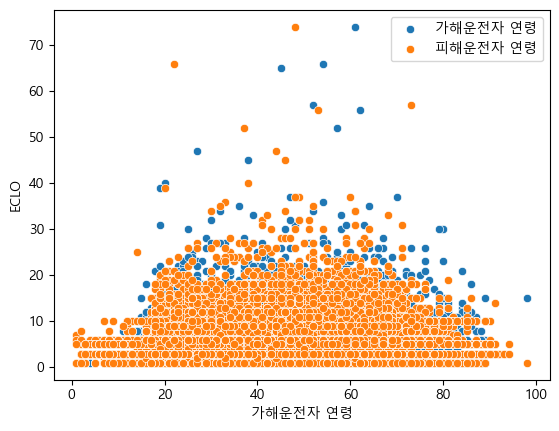

In [259]:
# 가해운전자 연령 : 피해운전자 연령 에 대해 피해 심각도(ECLO)의 관계 분석
# 가설피해 운전자 또는 피해운전자의연령이 높을수록 더 높은 ECLO값이 나올것으로 예상
sns.scatterplot(data=train,x='가해운전자 연령',y='ECLO',label='가해운전자 연령')
sns.scatterplot(data=train,x='피해운전자 연령',y='ECLO',label='피해운전자 연령')

<Axes: xlabel='시간', ylabel='ECLO'>

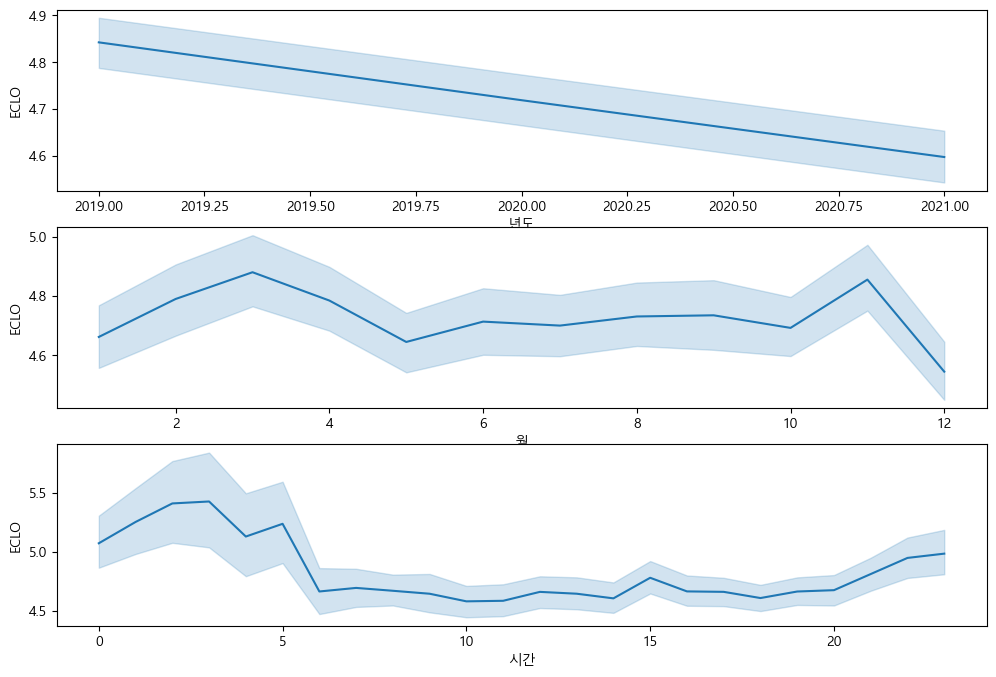

In [260]:
# 타겟변수 ECLO에 대한 연도 월 시간별 시계열 그래프 확인 분석
# 가설1  년도가 증가할수록 ECLO 낮을거 같다
# 가설2  공휴일에는 ECLO 높은거 같다      
# 가설2  공휴일에는 ECLO 높은거 같다
# 가설3  출퇴근 시간에 ECLO 높은거 같다

# 사고일시  컬럼에서 년도 월 일 시간을 분류해서 추가
# 년도   line
# 월  bar
# 시간  line
train['년도'] = pd.to_datetime(train['사고일시']).dt.year
train['월'] = pd.to_datetime(train['사고일시']).dt.month
train['일'] = pd.to_datetime(train['사고일시']).dt.day
train['시간'] = pd.to_datetime(train['사고일시']).dt.hour

plt.figure(figsize=(12,8))
plt.subplot(3,1,1)
sns.lineplot(data=train,x='년도', y='ECLO')

plt.subplot(3,1,2)
# sns.barplot(data=train,x='월', y='ECLO',hue='월',legend=False, palette='deep',)
sns.lineplot(data=train,x='월', y='ECLO')

plt.subplot(3,1,3)
sns.lineplot(data=train,x='시간', y='ECLO')

In [261]:
# 학생풀이
# 타켓 변수 ECLO에 대한 연도 월 시간별 시계열 그래프 확인 분석


In [262]:
type(train['사고일시'][15]) # 타입 str, strip사용
print(train['사고일시'][15])

2019-01-01 19


In [263]:
# 연도 월 시간 분류하기
train['연도'] = train['사고일시'].str.split("-",expand=True)[0]
train['월'] = train['사고일시'].str.split("-",expand=True)[1]
index_2 = train['사고일시'].str.split("-",expand=True)[2]
train['일'] = index_2.str.split(" ",expand=True)[0]
train['시간'] = index_2.str.split(" ",expand=True)[1]

In [264]:
train['연도'].head()

0    2019
1    2019
2    2019
3    2019
4    2019
Name: 연도, dtype: object

In [265]:
train['월'].head()

0    01
1    01
2    01
3    01
4    01
Name: 월, dtype: object

In [266]:
train['일'].head()

0    01
1    01
2    01
3    01
4    01
Name: 일, dtype: object

In [267]:
train['시간'].head()

0    00
1    00
2    01
3    02
4    04
Name: 시간, dtype: object

In [268]:
# 시계열 데이터 만들기
import pandas as pd

hour_df = pd.DataFrame({'hour': train['시간']})

In [269]:
# train['Year'] =  pd.to_datetime(train.Dates).dt.year
# train['Month'] =  pd.to_datetime(train.Dates).dt.month
# train['Day'] =  pd.to_datetime(train.Dates).dt.day
# train['Hour'] =  pd.to_datetime(train.Dates).dt.hour
# train['Minute'] =  pd.to_datetime(train.Dates).dt.minute

# train = train.drop(columns=['Dates'])

In [270]:
numeric_coulmns = train.describe().columns.to_list()
numeric_coulmns

['가해운전자 연령', '피해운전자 연령', '사망자수', '중상자수', '경상자수', '부상자수', 'ECLO', '년도']

In [271]:
train_numeric_data =train[numeric_coulmns]

c:\김지은\파이썬_src\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
c:\김지은\파이썬_src\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


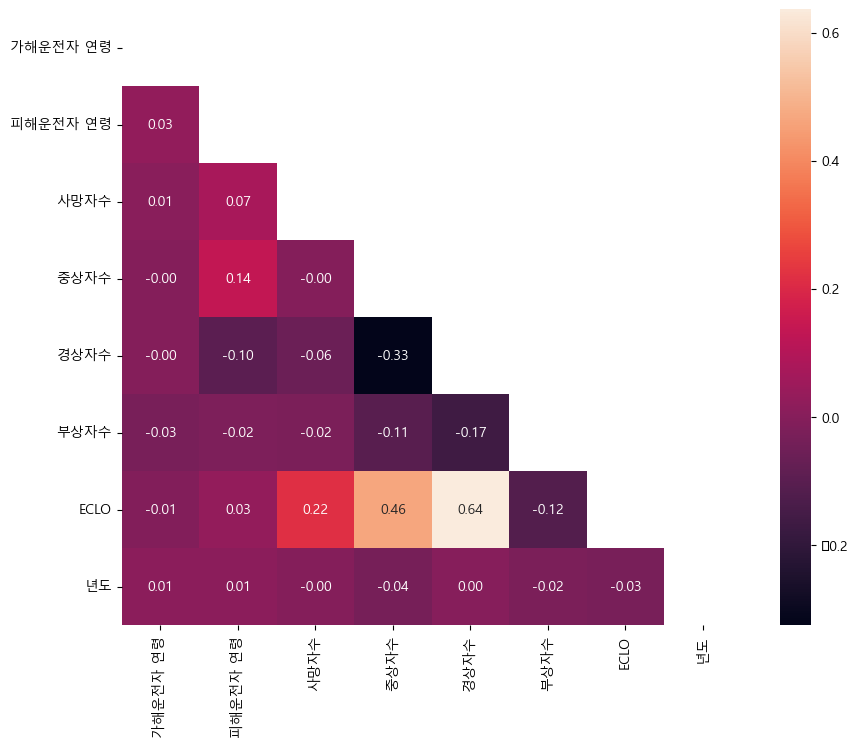

In [272]:
# 상관관계 heatmap
corr = train_numeric_data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
# np.triu() ^ np.triu()는 행렬의 상삼각 부분만 남기고 나머지를 0으로 만드는 함수
# k 파라미터로 대각선 위치 조정 가능 (k=0 기본, k>0 위쪽, k<0 아래쪽)
# 주로 상관관계 히트맵 마스크나 상삼각 행렬 추출에 사용됨.

# 히트맵 그리기
plt.figure(figsize=(10,8))
sns.heatmap(data=train_numeric_data.corr(),mask=mask,annot=True, fmt=".2f")
plt.show()

c:\김지은\파이썬_src\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()


<Axes: >

c:\김지은\파이썬_src\.venv\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  func(*args, **kwargs)
c:\김지은\파이썬_src\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


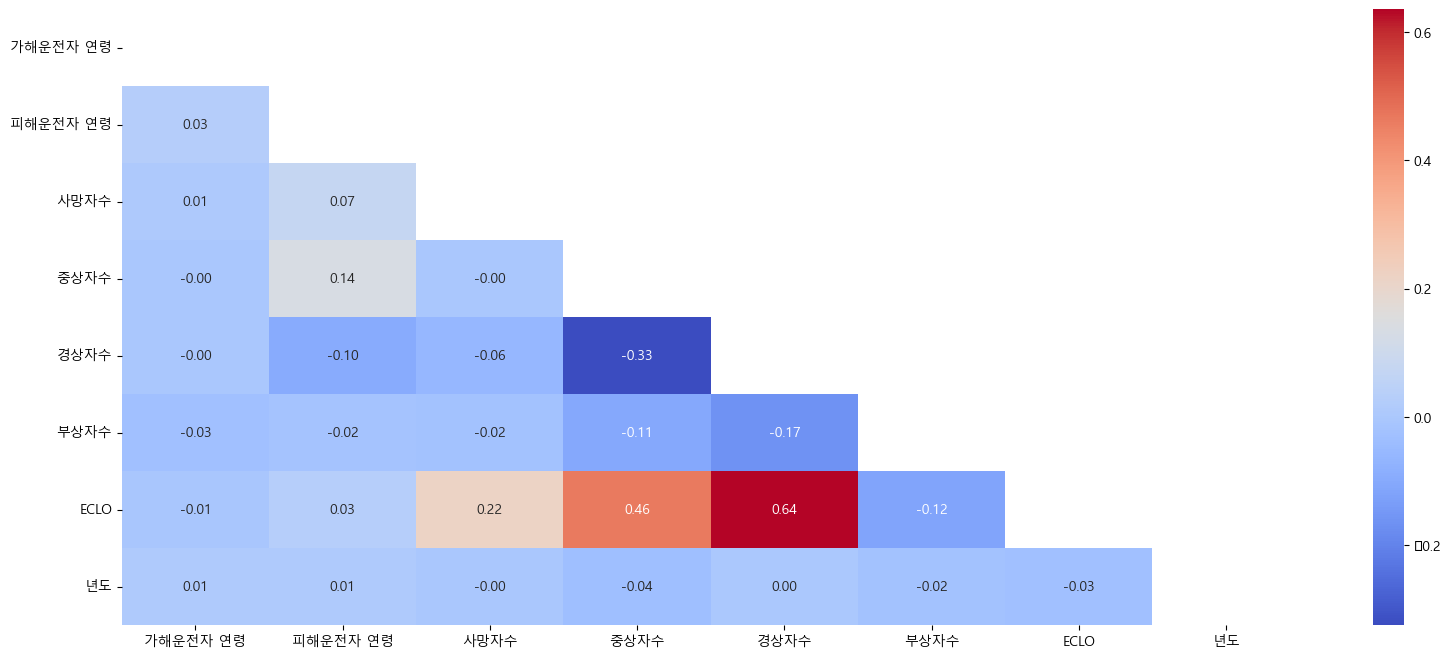

In [273]:
# 강사님 풀이
# 상관관계  heatmap
plt.figure(figsize=(19,8))
# 상관관계 행렬
corr = train.select_dtypes(exclude='object')[:-4].corr()

# 상삼각형 mask 만들기
mask = np.triu(np.ones_like(corr, dtype=bool))

# 히트맵 출력
sns.heatmap(
    corr,
    mask=mask,        # 삼각형 제거
    annot=True,       # 수치 표시
    cmap='coolwarm',  # 색상 맵
    fmt='.2f'         # 소수점 둘째 자리까지 표시
)

In [274]:
# 데이터 전처리 및 피쳐 엔지니어링

In [275]:
# 데이터 불러오기
test = pd.read_csv('C:/김지은/파이썬_src/pandas-data-analysis/part7/extracted_files/open/test.csv')
train = pd.read_csv('C:/김지은/파이썬_src/pandas-data-analysis/part7/extracted_files/open/train.csv')

In [276]:
# 사고일시 열의 시간 문자열 형태의 시간 데이터를 패턴을 입력하여 숫자(수치형 데이터)로 변환
time_pattern = r'(\d{4})-(\d{1,2})-(\d{1,2}) (\d{1,2})'  # 사고일시의 데이터 패턴을 입력 ^ r ^ 정규표현식 ^
train[['년', '월', '일', '시간']] = train['사고일시'].str.extract(time_pattern).apply(pd.to_numeric)
train_df = train.drop(columns=['사고일시'])

test[['년', '월', '일', '시간']] = test['사고일시'].str.extract(time_pattern).apply(pd.to_numeric)
test_df = train.drop(columns=['사고일시'])

In [277]:
test_df

,ID,요일,기상상태,시군구,도로형태,노면상태,사고유형,사고유형 - 세부분류,법규위반,가해운전자 차종,...,피해운전자 상해정도,사망자수,중상자수,경상자수,부상자수,ECLO,년,월,일,시간
0,ACCIDENT_00000,화요일,맑음,대구광역시 중구 대신동,단일로 - 기타,건조,차대사람,길가장자리구역통행중,안전운전불이행,승용,...,중상,0,1,0,0,5,2019,1,1,0
1,ACCIDENT_00001,화요일,흐림,대구광역시 달서구 감삼동,단일로 - 기타,건조,차대사람,보도통행중,기타,승용,...,경상,0,0,1,0,3,2019,1,1,0
2,ACCIDENT_00002,화요일,맑음,대구광역시 수성구 두산동,단일로 - 기타,건조,차대사람,차도통행중,안전운전불이행,승용,...,경상,0,0,1,0,3,2019,1,1,1
3,ACCIDENT_00003,화요일,맑음,대구광역시 북구 복현동,단일로 - 기타,건조,차대차,추돌,안전운전불이행,승용,...,중상,0,1,0,0,5,2019,1,1,2
4,ACCIDENT_00004,화요일,맑음,대구광역시 동구 신암동,단일로 - 기타,건조,차대차,추돌,안전운전불이행,승용,...,경상,0,0,1,0,3,2019,1,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39604,ACCIDENT_39604,금요일,맑음,대구광역시 수성구 수성동3가,교차로 - 교차로안,건조,차대차,측면충돌,신호위반,승용,...,경상,0,0,1,0,3,2021,12,31,19
39605,ACCIDENT_39605,금요일,맑음,대구광역시 달서구 상인동,단일로 - 기타,건조,차대차,측면충돌,안전거리미확보,승용,...,경상,0,0,1,0,3,2021,12,31,19
39606,ACCIDENT_39606,금요일,맑음,대구광역시 달서구 월성동,교차로 - 교차로안,건조,차대차,측면충돌,교차로운행방법위반,승용,...,중상,0,2,0,0,10,2021,12,31,21
39607,ACCIDENT_39607,금요일,맑음,대구광역시 달서구 장동,기타 - 기타,건조,차대차,추돌,안전운전불이행,승용,...,경상,0,0,1,0,3,2021,12,31,22


In [278]:
# 위치 특성 추출 : ECLO가 높은 시군구가 있다는 것을 확인
# 시군구
local_pattern = r'(\S+) (\S+) (\S+)' # 서울시 강남구 대치동 # 시군구의 데이터 패턴을 정규표현식으로 입력
train_df[['도시', '구', '동']] = train['시군구'].str.extract(local_pattern)
train_df = train_df.drop(columns=['시군구'])
# train_df = train.drop(columns=['시군구']) # 시군구를 제외한 train을 train_df에 덮어씌움
                                            # train_df 에서 시군구를 도시 구 동 으로 나눈 데이터 프레임을 덮어씌웠어야됬다!

test_df[['도시', '구', '동']] = test['시군구'].str.extract(local_pattern)
test_df = test_df.drop(columns=['시군구'])

In [279]:
train['시군구'].str.extract(local_pattern)

,0,1,2
0,대구광역시,중구,대신동
1,대구광역시,달서구,감삼동
2,대구광역시,수성구,두산동
3,대구광역시,북구,복현동
4,대구광역시,동구,신암동
...,...,...,...
39604,대구광역시,수성구,수성동3가
39605,대구광역시,달서구,상인동
39606,대구광역시,달서구,월성동
39607,대구광역시,달서구,장동


In [280]:
column_list = train_df.columns.tolist()
column_list

['ID',
 '요일',
 '기상상태',
 '도로형태',
 '노면상태',
 '사고유형',
 '사고유형 - 세부분류',
 '법규위반',
 '가해운전자 차종',
 '가해운전자 성별',
 '가해운전자 연령',
 '가해운전자 상해정도',
 '피해운전자 차종',
 '피해운전자 성별',
 '피해운전자 연령',
 '피해운전자 상해정도',
 '사망자수',
 '중상자수',
 '경상자수',
 '부상자수',
 'ECLO',
 '년',
 '월',
 '일',
 '시간',
 '도시',
 '구',
 '동']

In [281]:
train_df['도로형태'].unique()

array(['단일로 - 기타', '교차로 - 교차로안', '기타 - 기타', '단일로 - 터널', '단일로 - 지하차도(도로)내',
       '단일로 - 교량', '교차로 - 교차로횡단보도내', '주차장 - 주차장', '교차로 - 교차로부근',
       '단일로 - 고가도로위', '미분류 - 미분류'], dtype=object)

In [282]:
# 도로형태
road_pattern = r'(.+?)\s*-\s*(.+)'
train_df[['도로형태1', '도로형태2']] = train_df['도로형태'].str.extract(road_pattern)
train_df = train_df.drop(columns=['도로형태'])

test_df[['도로형태1', '도로형태2']] = test_df['도로형태'].str.extract(road_pattern)
test_df = test_df.drop(columns=['도로형태'])

column_list = train_df.columns.tolist()
column_list

['ID',
 '요일',
 '기상상태',
 '노면상태',
 '사고유형',
 '사고유형 - 세부분류',
 '법규위반',
 '가해운전자 차종',
 '가해운전자 성별',
 '가해운전자 연령',
 '가해운전자 상해정도',
 '피해운전자 차종',
 '피해운전자 성별',
 '피해운전자 연령',
 '피해운전자 상해정도',
 '사망자수',
 '중상자수',
 '경상자수',
 '부상자수',
 'ECLO',
 '년',
 '월',
 '일',
 '시간',
 '도시',
 '구',
 '동',
 '도로형태1',
 '도로형태2']

In [283]:
train_df['가해운전자 연령']

0        51세
1        39세
2        70세
3        49세
4        30세
        ... 
39604    52세
39605    60세
39606    60세
39607    40세
39608    27세
Name: 가해운전자 연령, Length: 39609, dtype: object

In [284]:
pattern = r'(\d+)'
train_df['가해운전자 연령'] = train_df['가해운전자 연령'].str.extract(pattern).astype(float)
train_df['피해운전자 연령'] = train_df['피해운전자 연령'].str.extract(pattern).astype(float) 

In [285]:
train_df.columns

Index(['ID', '요일', '기상상태', '노면상태', '사고유형', '사고유형 - 세부분류', '법규위반', '가해운전자 차종',
       '가해운전자 성별', '가해운전자 연령', '가해운전자 상해정도', '피해운전자 차종', '피해운전자 성별',
       '피해운전자 연령', '피해운전자 상해정도', '사망자수', '중상자수', '경상자수', '부상자수', 'ECLO', '년',
       '월', '일', '시간', '도시', '구', '동', '도로형태1', '도로형태2'],
      dtype='object')

In [286]:
# 지역별 평균 연령 추출 및 데이터 병합 %
# 도시별로 가해운전자 연령별+피해운전자 연령별 수치를 보여주기.
# 가해자 운전자 연령과 피해자 운전자 연령의 평균을 지역별로 계산 -> 원본데이터와 병합
# 지역 단위는 도시 단위로, 같은 시별로 치기
age_mean = train_df[['도시','구','동','가해운전자 연령','피해운전자 연령']].groupby(['도시','구','동']).mean()
age_mean.columns = ['가해운전자 평균연령', '피해운전자 평균연령']
train_df = pd.merge(train_df, age_mean, how='left', on = ['도시','구','동'])
test_df = pd.merge(test_df, age_mean, how='left', on = ['도시','구','동'])
train_df['가해운전자 평균연령'].head()

0    52.714286
1    47.176383
2    47.008547
3    46.894089
4    49.426415
Name: 가해운전자 평균연령, dtype: float64

In [287]:
# 지역별 평균 성별

In [288]:
# 성별 데이터 남 : 1, 여 : 0 로 매핑하여, 범주형데이터를 수치형데이터로 전환
train_df['가해운전자 성별'] = train_df['가해운전자 성별'].map({'남':1, '여':0})
train_df['피해운전자 성별'] = train_df['피해운전자 성별'].map({'남':1, '여':0})

In [290]:
# 지역별 평균 성별
gender_mean = train_df[['도시','구','동','가해운전자 성별','피해운전자 성별']].groupby(['도시','구','동']).mean()
gender_mean.columns = ['가해운전자 평균성별','피해운전자 평균성별']
train_df = pd.merge(train_df,gender_mean,how='left',on = ['도시','구','동'])
test_df = pd.merge(test_df,gender_mean,how='left',on = ['도시','구','동'])
train_df.head()

,ID,요일,기상상태,노면상태,사고유형,사고유형 - 세부분류,법규위반,가해운전자 차종,가해운전자 성별,가해운전자 연령,...,시간,도시,구,동,도로형태1,도로형태2,가해운전자 평균연령,피해운전자 평균연령,가해운전자 평균성별,피해운전자 평균성별
0,ACCIDENT_00000,화요일,맑음,건조,차대사람,길가장자리구역통행중,안전운전불이행,승용,0.0,51.0,...,0,대구광역시,중구,대신동,단일로,기타,52.714286,48.015504,0.753968,0.604651
1,ACCIDENT_00001,화요일,흐림,건조,차대사람,보도통행중,기타,승용,1.0,39.0,...,0,대구광역시,달서구,감삼동,단일로,기타,47.176383,42.906767,0.744395,0.732331
2,ACCIDENT_00002,화요일,맑음,건조,차대사람,차도통행중,안전운전불이행,승용,1.0,70.0,...,1,대구광역시,수성구,두산동,단일로,기타,47.008547,43.270134,0.747009,0.756711
3,ACCIDENT_00003,화요일,맑음,건조,차대차,추돌,안전운전불이행,승용,1.0,49.0,...,2,대구광역시,북구,복현동,단일로,기타,46.894089,42.943902,0.800493,0.714634
4,ACCIDENT_00004,화요일,맑음,건조,차대차,추돌,안전운전불이행,승용,1.0,30.0,...,4,대구광역시,동구,신암동,단일로,기타,49.426415,47.400254,0.779874,0.738247


In [292]:
# 주말특성  토,일  1  나머지는 0
train_df['주말'] = train_df['요일'].apply(lambda x : 1 if x in ['토요일','일요일'] else 0)
test_df['주말'] = test_df['요일'].apply(lambda x : 1 if x in ['토요일','일요일'] else 0)

##### 데이터 전처리 및 피처엔지니어링 심화
![화면 캡처 2025-10-17 171626.png](<attachment:화면 캡처 2025-10-17 171626.png>)
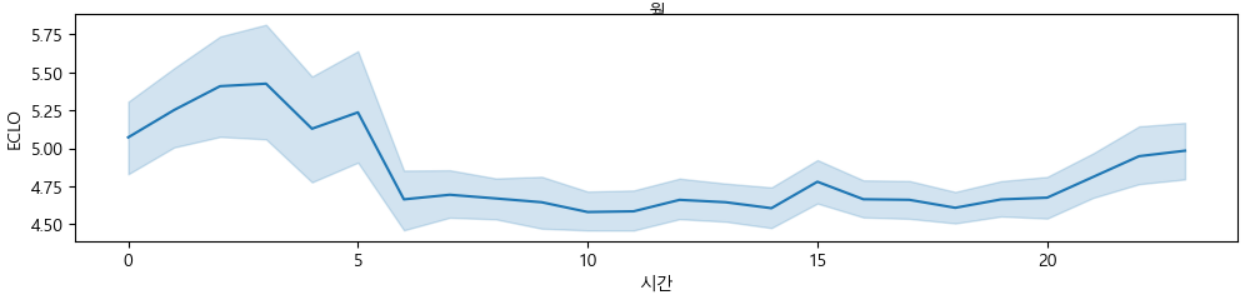

In [293]:
# 야간의 시인성 저하에 의해서 교통사고 발생확률을 예측하는데 반영  = 한국표준과학연구원_천문역법참조표준데이터_20161201.xlsx
from glob import glob
csvs = glob('./extracted_files/**/*.*',recursive=True)
csvs

[]

In [294]:
# 지역별 사고 유형에 따른 차량 종류의 위험도 산출 및 데이터 병합
# 사고 유형과 차종별 사고 빈도는 지역별로 각기 다른 특성을 가진다  -ECLO의 주요 요인
# 파생변수 : 가해운전자 차종의 ECLO와 가해 운전자 차종 건수를 곱해 차종별 위험도 파생변수
ride_dangerous = train_df[['가해운전자 차종','ECLO']].groupby('가해운전자 차종').mean()
ride_dangerous.columns = ['ride_dangerous']

ride_count = train_df[['도시','구','가해운전자 차종']]
ride_count['count'] = 1
ride_count = ride_count.groupby(['도시','구','가해운전자 차종']).count().reset_index()
temp_1 = pd.merge(ride_count , ride_dangerous, how='left', on=['가해운전자 차종'])
temp_1['multiply'] = temp_1['count'] * temp_1['ride_dangerous']
temp_1 = temp_1.groupby(['도시','구']).sum().reset_index().drop(columns=['ride_dangerous'])
temp_1['ride_dangerous'] = temp_1['multiply'] / temp_1['count']
temp_1 = temp_1.drop(columns=['가해운전자 차종',	'count',	'multiply'])
temp_1

train_df = pd.merge(train_df, temp_1, how='left',on=['도시','구'])
test_df = pd.merge(test_df, temp_1, how='left',on=['도시','구'])
test_df

C:\Users\Playdata2\AppData\Local\Temp\ipykernel_2132\1822720510.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ride_count['count'] = 1


,ID,요일,기상상태,노면상태,사고유형,사고유형 - 세부분류,법규위반,가해운전자 차종,가해운전자 성별,가해운전자 연령,...,구,동,도로형태1,도로형태2,가해운전자 평균연령,피해운전자 평균연령,가해운전자 평균성별,피해운전자 평균성별,주말,ride_dangerous
0,ACCIDENT_00000,화요일,맑음,건조,차대사람,길가장자리구역통행중,안전운전불이행,승용,여,51세,...,수성구,상동,단일로,기타,46.719033,44.303951,0.728097,0.677812,0,4.757166
1,ACCIDENT_00001,화요일,흐림,건조,차대사람,보도통행중,기타,승용,남,39세,...,수성구,지산동,단일로,기타,47.977273,46.119247,0.685950,0.658996,0,4.757166
2,ACCIDENT_00002,화요일,맑음,건조,차대사람,차도통행중,안전운전불이행,승용,남,70세,...,수성구,수성동2가,단일로,기타,46.923077,45.321678,0.818182,0.664336,0,4.757166
3,ACCIDENT_00003,화요일,맑음,건조,차대차,추돌,안전운전불이행,승용,남,49세,...,수성구,신매동,단일로,기타,47.569061,43.263014,0.671271,0.654795,0,4.757166
4,ACCIDENT_00004,화요일,맑음,건조,차대차,추돌,안전운전불이행,승용,남,30세,...,달서구,감삼동,단일로,기타,47.176383,42.906767,0.744395,0.732331,0,4.745864
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39604,ACCIDENT_39604,금요일,맑음,건조,차대차,측면충돌,신호위반,승용,여,52세,...,NaN,NaN,교차로,교차로안,NaN,NaN,NaN,NaN,0,NaN
39605,ACCIDENT_39605,금요일,맑음,건조,차대차,측면충돌,안전거리미확보,승용,여,60세,...,NaN,NaN,단일로,기타,NaN,NaN,NaN,NaN,0,NaN
39606,ACCIDENT_39606,금요일,맑음,건조,차대차,측면충돌,교차로운행방법위반,승용,남,60세,...,NaN,NaN,교차로,교차로안,NaN,NaN,NaN,NaN,0,NaN
39607,ACCIDENT_39607,금요일,맑음,건조,차대차,추돌,안전운전불이행,승용,남,40세,...,NaN,NaN,기타,기타,NaN,NaN,NaN,NaN,0,NaN


In [ ]:
# 전체 코드의 목적:
# 차종별 사고 위험도 계산 (ride_dangerous)
# 지역별 차종 사고 빈도 계산 (ride_count)
# 차종별 위험도 × 사고 건수 계산 (multiply)
# 지역별 총 위험 점수 산출 (groupby(['도시','구']).sum())

# 그룹바이를 해서 원하는 정보를 조회할수있게 하는것, 피처 엔지니어링을 하기 ^

# 결과적으로 조회할 수 있는 정보:
# 각 지역(도시/구)에서 전체 사고 위험 수준
# 어떤 지역이 사고가 많고 위험도가 높은 차종이 많은지 파악 가능
# 정책, 보험, 안전 캠페인 등 의사결정 지표로 활용 가능

In [ ]:
# 필요 없는 열을 제거
# 범주형 데이터는 원핫, 만약순서나 크기가 있는 범주형은 라벨형태 그대로 유지, 범주간의 차이를 학습
# 모델 : RandomForest
# gridSearch를 통하여 하이퍼 파라미터 튜닝
# 대회의 경우에는 : test_df를 예측해서 제출